# Regresión

Samantha Sánchez Tinoco

Oscar Josue Rocha Hernández

Viviana Toledo De la Fuente

## Definición del Problema

Con el propósito de comprender cómo las políticas en torno a la comunidad LGBTQIA+ afectan las condiciones de equidad y estado de derecho en los países alrededor del mundo, se encontraron datasets que detallan las leyes en materia de orientación sexual, así como indicadores sobre la equidad en los países. De esta manera, utilizando ambas bases de datos, se trazará un modelo de regresión.

El primer dataset comprende leyes sobre orientación sexual en el mundo, como la criminalización del acto, las penas aplicadas, protecciones constitucionales, reconocimientos matrimoniales, etcétera. Esta base de datos fue recolectada en Kaggle, cargada por Marília Prata en 2020, según los datos recopilados por _ILGA WORLD_, una asociación internacional de Lesbianas, Gays, Bisexuales, Trans e Intersexuales que reporta los avances en materia legal de la comunidad queer.

Sitio web de _ILGA WORLD_: https://ilga.org/ilga-world-maps/

El segundo dataset proviene de _Equaldex_, una organización que también se encarga de monitorear los avances en materia legal de la comunidad LGBTQIA+, pero que además proporciona indicadores de equidad, legalidad y opinión pública. Debido a que el dataset previo no contiene una variable predictora, se utilizarán los indicadores de Equaldex para completar el problema de regresión. Sin embargo, estos datos fueron actualizados en 2024, lo que presenta un problema de temporalidad entre ambos datasets. 

Sitio web de _Equaldex_: https://www.equaldex.com

Todos los derechos reservados para _ILGA WORLD_ y _Equaldex_, este trabajo tiene fines meramente académicos y de difusión. 

## EDA

In [1]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OrdinalEncoder
from imblearn.over_sampling import SMOTE

In [2]:
laws = pd.read_csv('sexual_orientation_laws.csv', encoding='latin-1', sep=';')
laws.columns = ['Country', 'CSSSA decrim?', 'Date of decrim', 'Max Penalty', 'Const. Prot.', 'Broad Prot.', 'Employ. Prot', 
                'Hate Crime Illegal?', 'Incitement', 'Ban Conv. Therapies', 'Same Sex Marriage', 'Civil Unions', 'Joint Adoption',
                'Second Parent Adoption']
laws.head()

,Country,CSSSA decrim?,Date of decrim,Max Penalty,Const. Prot.,Broad Prot.,Employ. Prot,Hate Crime Illegal?,Incitement,Ban Conv. Therapies,Same Sex Marriage,Civil Unions,Joint Adoption,Second Parent Adoption
0,Algeria,NO,-,2,NO,NO,NO,NO,NO,NO,NO,NO,NO,NO
1,Angola,YES,2021,-,NO,YES,YES,YES,YES,NO,NO,NO,NO,NO
2,Benin,YES,NEVER CRIM,-,NO,NO,NO,NO,NO,NO,NO,NO,NO,NO
3,Botswana,YES,2019,-,NO,NO,YES,NO,NO,NO,NO,NO,NO,NO
4,Burkina Faso,YES,NEVER CRIM,-,NO,NO,NO,NO,NO,NO,NO,NO,NO,NO


#### Desglose de las variables
CSSSA decrim?: Se refiere a la decriminalización de actos sexuales consensuados entre adultos del mismo sexo.

Date of decrim: Fecha de decriminalización del CSSSA.

Max Penalty: Pena máxima en los países donde el CSSSA todavía está criminalizado.

Protecciones Constitucionales

Protecciones Generales

Protecciones Laborales

Criminalización de Crímenes de Odio 

Criminalización de la Incitación a la Violencia

Prohibición de las 'Terapias de Conversión'

Matrimonio Igualitario

Uniones Civiles

Adopción Legal

Adopción Coparental

In [3]:
laws.shape

(241, 14)

El dataset contiene 241 instancias, con 1 ID y 13 features. Las 241 instancias se deben a que Ilga World también contempla regiones específicas en su análisis.

In [4]:
index = pd.read_csv('equaldex_equality_index.csv')
index = index.rename(columns={'Name': 'Country'}).drop('Region ID', axis=1)
index.head()

,Country,EI,EI Legal,EI PO
0,Iceland,93,95,90.0
1,Norway,87,87,87.0
2,Uruguay,83,93,73.0
3,Spain,82,97,67.0
4,Chile,81,100,61.0


#### Desglose de las Variables

El dataset de Equaldex contiene 3 indicadores: el indicador de equidad, el indicador legal y el indicador de opinión pública.

El indicador de equidad es un promedio de los otros dos indicadores. Como consecuencia de esto, la correlación será muy alta, por lo que droppearemos esta variable. Asimismo, debido a que contamos con datos legislativos, se usará el índice legal. 

In [5]:
index.shape

(196, 4)

Esta base de datos contiene 1 ID y 3 variables predictoras, de las cuales se quitarán 2 por razones antes mencionadas. Además, contiene 196 instancias, que corresponden a los países del mundo. Debido a la diferencia de filas entre ambos datasets, se unirán en base a las coincidencias.

In [6]:
index = index.drop(['EI', 'EI PO'], axis=1)
df = pd.merge(laws, index, on='Country', how='inner')
df.head()

,Country,CSSSA decrim?,Date of decrim,Max Penalty,Const. Prot.,Broad Prot.,Employ. Prot,Hate Crime Illegal?,Incitement,Ban Conv. Therapies,Same Sex Marriage,Civil Unions,Joint Adoption,Second Parent Adoption,EI Legal
0,Algeria,NO,-,2,NO,NO,NO,NO,NO,NO,NO,NO,NO,NO,3
1,Angola,YES,2021,-,NO,YES,YES,YES,YES,NO,NO,NO,NO,NO,66
2,Benin,YES,NEVER CRIM,-,NO,NO,NO,NO,NO,NO,NO,NO,NO,NO,42
3,Botswana,YES,2019,-,NO,NO,YES,NO,NO,NO,NO,NO,NO,NO,59
4,Burkina Faso,YES,NEVER CRIM,-,NO,NO,NO,NO,NO,NO,NO,NO,NO,NO,49


In [7]:
pd.DataFrame(df.isnull().sum(), columns=['valores_nulos'])

,valores_nulos
Country,0
CSSSA decrim?,0
Date of decrim,1
Max Penalty,0
Const. Prot.,0
Broad Prot.,0
Employ. Prot,0
Hate Crime Illegal?,0
Incitement,0
Ban Conv. Therapies,0


Contamos con un único valor nulo en la fecha de decriminalización del CSSSA. 

In [8]:
df[df['Date of decrim'].isnull()]

,Country,CSSSA decrim?,Date of decrim,Max Penalty,Const. Prot.,Broad Prot.,Employ. Prot,Hate Crime Illegal?,Incitement,Ban Conv. Therapies,Same Sex Marriage,Civil Unions,Joint Adoption,Second Parent Adoption,EI Legal
87,Iraq,DE FACTO,NaN,UNDETERM.,NO,NO,NO,NO,NO,NO,NO,NO,NO,NO,4


Actualizando los valores para Iraq según la base de datos de ILGA WORLD (https://database.ilga.org/criminalisation-consensual-same-sex-sexual-acts):

In [9]:
row_index = df[df['Country'] == 'Iraq'].index[0]
df.loc[row_index, 'Date of decrim'] = '-'
df.loc[row_index, 'CSSSA decrim?'] = 'NO'
df.loc[row_index, 'Max Penalty'] = '15'

In [10]:
df[df['Country'] == 'Iraq']

,Country,CSSSA decrim?,Date of decrim,Max Penalty,Const. Prot.,Broad Prot.,Employ. Prot,Hate Crime Illegal?,Incitement,Ban Conv. Therapies,Same Sex Marriage,Civil Unions,Joint Adoption,Second Parent Adoption,EI Legal
87,Iraq,NO,-,15,NO,NO,NO,NO,NO,NO,NO,NO,NO,NO,4


In [11]:
pd.DataFrame(df.nunique(), columns=['Valores_únicos'])

,Valores_únicos
Country,181
CSSSA decrim?,3
Date of decrim,73
Max Penalty,16
Const. Prot.,2
Broad Prot.,3
Employ. Prot,3
Hate Crime Illegal?,3
Incitement,3
Ban Conv. Therapies,3


In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 181 entries, 0 to 180
Data columns (total 15 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   Country                 181 non-null    object
 1   CSSSA decrim?           181 non-null    object
 2   Date of decrim          181 non-null    object
 3   Max Penalty             181 non-null    object
 4   Const. Prot.            181 non-null    object
 5   Broad Prot.             181 non-null    object
 6   Employ. Prot            181 non-null    object
 7   Hate Crime Illegal?     181 non-null    object
 8   Incitement              181 non-null    object
 9   Ban Conv. Therapies     181 non-null    object
 10  Same Sex Marriage       181 non-null    object
 11  Civil Unions            181 non-null    object
 12  Joint Adoption          181 non-null    object
 13  Second Parent Adoption  181 non-null    object
 14  EI Legal                181 non-null    int64 
dtypes: int

Las features contienen exclusivamente valores categóricos, en su mayoría aceptando de 2 a 3 valores. Mientras que la target es una variable numérica. Esto significa que todas las features necesitan ser codificadas. Por la naturaleza de los datos, que hasta cierto punto se basan en rankings, se utilizará una codificación ordinal.

In [13]:
X = df.drop(['EI Legal', 'Country'], axis=1)
y = df[['EI Legal']]

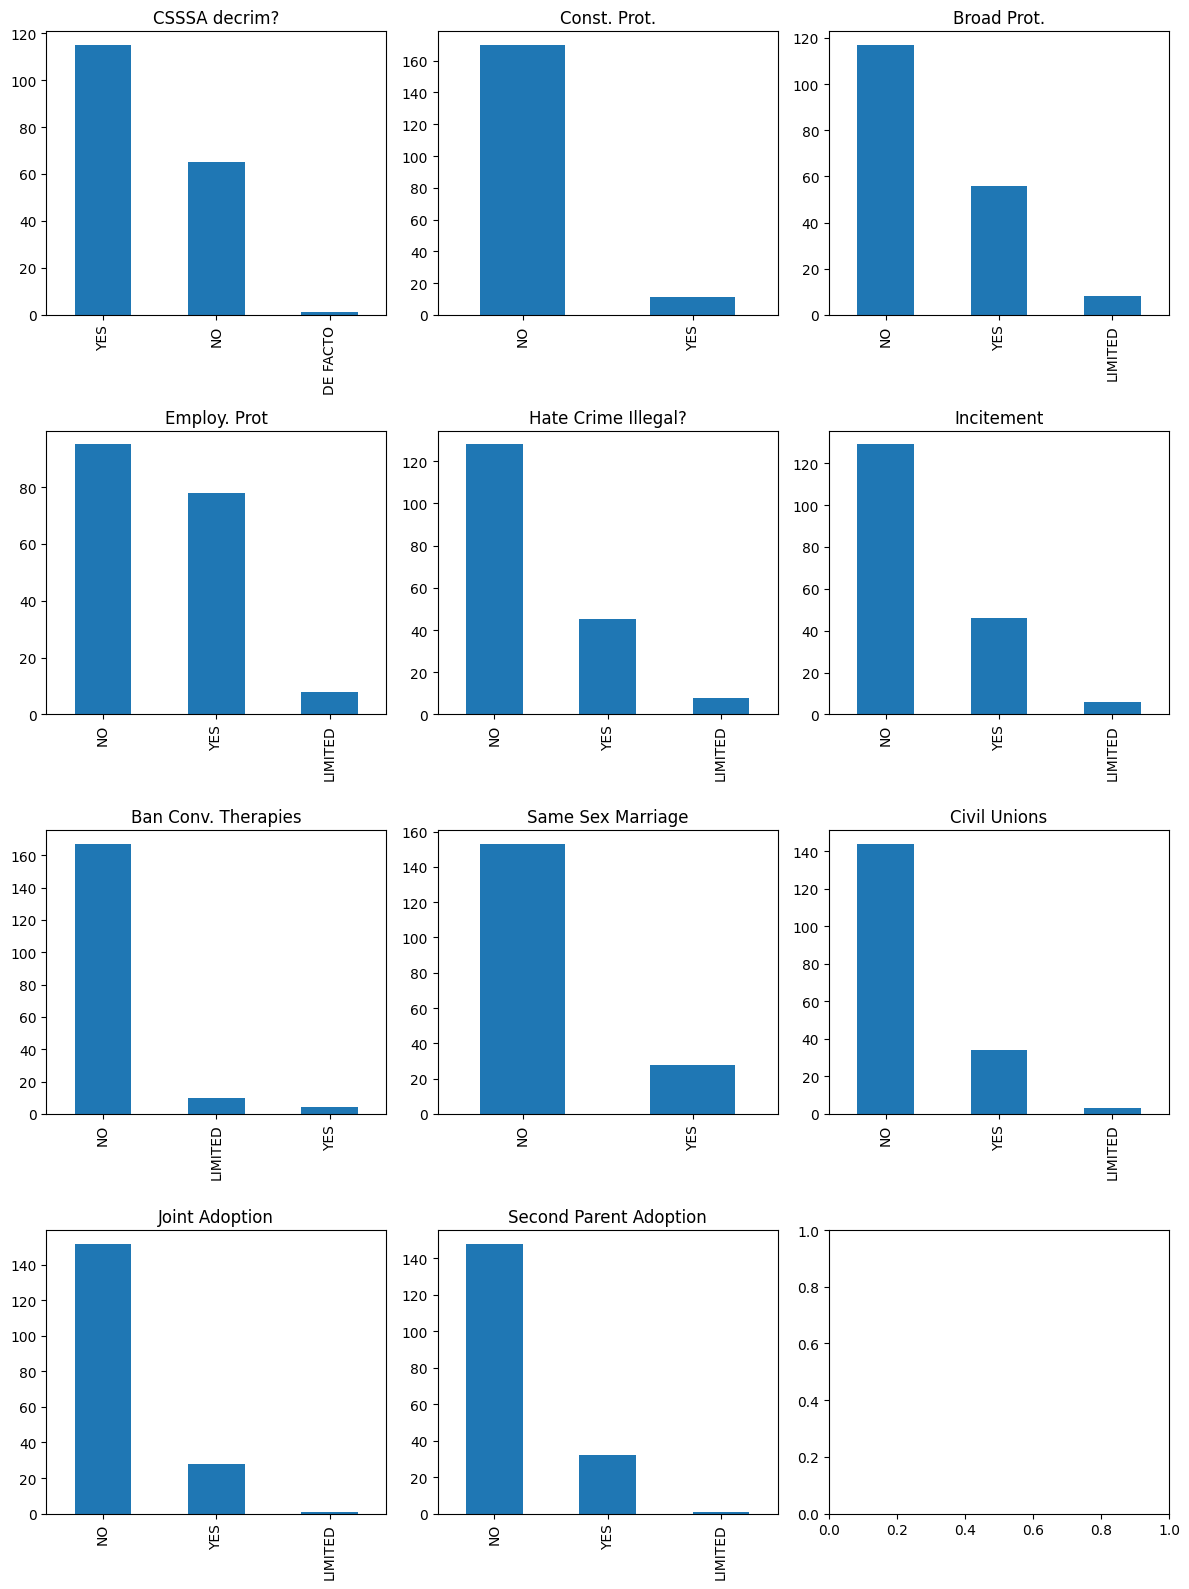

In [14]:
# Estableciendo las features a graficar
features = df.drop(['EI Legal', 'Country', 'Date of decrim', 'Max Penalty'], axis=1)

# Estableciendo el número de subplots con las columnas y filas del df
num_cols = len(features.columns)
cols = 3  
rows = np.ceil(num_cols / cols).astype(int)  

# Armando los subplots
fig, axes = plt.subplots(rows, cols, figsize=(12, rows * 4))
axes = axes.flatten()  

# Graficando cada variable
for i, var in enumerate(features.columns): 
    X[var].value_counts().plot(kind='bar', ax=axes[i])
    axes[i].set_title(var)
    axes[i].set_xlabel('')
    
plt.tight_layout()
plt.show()

Como se puede observar en los gráficos de arriba, muchos países presentan un rezago significativo en cuanto a las protecciones y derechos de la comunidad LGBTQIA+. La única variable donde los negativos son más pequeños es en la decriminalización de los actos sexuales consensuados entre adultos, que es una concesión mínima para el colectivo. 

Variables donde los positivos son casi iguales que los negativos ocurren en las protecciones laborales y generales, que, de nuevo, son derechos básicos para la comunidad. 

In [15]:
pd.DataFrame(df['Date of decrim'].value_counts())

,count
Date of decrim,
-,66
NEVER CRIM,13
1998,5
1993,4
1994,3
...,...
2021,1
1961,1
2007,1


En cuanto a las features excluidas en el análisis anterior, la fecha de decriminalización de CSSSA cuenta con una variedad de años, 'nunca se criminalizó' y '-' que corresponde a aquellos países que todavía criminalizan las prácticas.  

In [16]:
pd.DataFrame(df['Max Penalty'].value_counts())

,count
Max Penalty,
-,115
10,10
3,9
14,6
FOR LIFE,6
2,5
5,5
DEATH (P),5
7,4


En cuanto a las penas por CSSSA, tenemos una variedad de años en la cárcel, 'por vida', 'muerte (posible)', 'muerte', 'varía', 'indeterminado', y '-'. Tanto para esta variable como para la anterior, la codificación ordinal tiene que ser consciente y específica para representar la gravedad de los datos.

## Limpieza y Tratamiento de Datos

Nuestro dataset contenía un único dato faltante, que tratamos en la sección anterior para poder realizar el EDA. Para el tratamiento de datos, primero tenemos que hacer una codificación de todas las features y después un escalamiento.

### 1. Codificación de las Features

In [17]:
# Codificar las features
code = {'YES':0, 'NO':1, 'DE FACTO':0.5}
X['CSSSA decrim?'] = X['CSSSA decrim?'].map(code)

code = {'YES':0, 'NO':1, 'LIMITED':0.5}
X.iloc[:, 3:] = X.iloc[:, 3:].replace(code)

X.head()

C:\Users\samys\AppData\Local\Temp\ipykernel_13616\909751463.py:6: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  X.iloc[:, 3:] = X.iloc[:, 3:].replace(code)


,CSSSA decrim?,Date of decrim,Max Penalty,Const. Prot.,Broad Prot.,Employ. Prot,Hate Crime Illegal?,Incitement,Ban Conv. Therapies,Same Sex Marriage,Civil Unions,Joint Adoption,Second Parent Adoption
0,1.0,-,2,1,1.0,1.0,1.0,1.0,1.0,1,1.0,1.0,1.0
1,0.0,2021,-,1,0.0,0.0,0.0,0.0,1.0,1,1.0,1.0,1.0
2,0.0,NEVER CRIM,-,1,1.0,1.0,1.0,1.0,1.0,1,1.0,1.0,1.0
3,0.0,2019,-,1,1.0,0.0,1.0,1.0,1.0,1,1.0,1.0,1.0
4,0.0,NEVER CRIM,-,1,1.0,1.0,1.0,1.0,1.0,1,1.0,1.0,1.0


In [18]:
code = {'-':0, 'UNDETERM.':1, '1':2, '2':3, '3':4, '5':5, '7':6, '8':7, '10':8, '14':9, '15':10, '20':11, 'VARIES':12, 'FOR LIFE':13, 
        'DEATH (P)':14, 'DEATH':15}
X['Max Penalty'] = X['Max Penalty'].map(code)
X.head()

,CSSSA decrim?,Date of decrim,Max Penalty,Const. Prot.,Broad Prot.,Employ. Prot,Hate Crime Illegal?,Incitement,Ban Conv. Therapies,Same Sex Marriage,Civil Unions,Joint Adoption,Second Parent Adoption
0,1.0,-,3,1,1.0,1.0,1.0,1.0,1.0,1,1.0,1.0,1.0
1,0.0,2021,0,1,0.0,0.0,0.0,0.0,1.0,1,1.0,1.0,1.0
2,0.0,NEVER CRIM,0,1,1.0,1.0,1.0,1.0,1.0,1,1.0,1.0,1.0
3,0.0,2019,0,1,1.0,0.0,1.0,1.0,1.0,1,1.0,1.0,1.0
4,0.0,NEVER CRIM,0,1,1.0,1.0,1.0,1.0,1.0,1,1.0,1.0,1.0


In [19]:
# Codificar las features
encoder = OrdinalEncoder()

code = {'NEVER CRIM':'0', '-':'3000'}
X['Date of decrim'] = X['Date of decrim'].replace(code)

X['Date of decrim'] = encoder.fit_transform(X[['Date of decrim']])
encoder.fit(X)
X.head()

,CSSSA decrim?,Date of decrim,Max Penalty,Const. Prot.,Broad Prot.,Employ. Prot,Hate Crime Illegal?,Incitement,Ban Conv. Therapies,Same Sex Marriage,Civil Unions,Joint Adoption,Second Parent Adoption
0,1.0,72.0,3,1,1.0,1.0,1.0,1.0,1.0,1,1.0,1.0,1.0
1,0.0,71.0,0,1,0.0,0.0,0.0,0.0,1.0,1,1.0,1.0,1.0
2,0.0,0.0,0,1,1.0,1.0,1.0,1.0,1.0,1,1.0,1.0,1.0
3,0.0,69.0,0,1,1.0,0.0,1.0,1.0,1.0,1,1.0,1.0,1.0
4,0.0,0.0,0,1,1.0,1.0,1.0,1.0,1.0,1,1.0,1.0,1.0


In [20]:
pd.DataFrame(X['Date of decrim'].value_counts()).sort_values('Date of decrim')

,count
Date of decrim,
0.0,13
1.0,2
2.0,1
3.0,2
4.0,1
...,...
68.0,2
69.0,1
70.0,1


Comprobando la codificación para la fecha de decriminalización, todo está bien :)

### 2. Train/test split

In [21]:
# Se separan los datos en train, test. Con una división 70-30. 
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=69)

### 3. Escalamiento

In [22]:
# Pipeline para escalar las características (X)
X_transformer = Pipeline(steps=[
    ('scaler', StandardScaler())
])

# Ajustar y transformar X
X_train_transformed = X_transformer.fit_transform(X_train)
X_test_transformed = X_transformer.transform(X_test)


In [23]:
X_train_transformed = pd.DataFrame(X_train_transformed, columns=X_train.columns)
X_test_transformed = pd.DataFrame(X_test_transformed, columns=X_test.columns)

X_train_transformed.head()

,CSSSA decrim?,Date of decrim,Max Penalty,Const. Prot.,Broad Prot.,Employ. Prot,Hate Crime Illegal?,Incitement,Ban Conv. Therapies,Same Sex Marriage,Civil Unions,Joint Adoption,Second Parent Adoption
0,-0.73252,-1.698979,-0.591893,0.260378,0.784752,-0.024304,0.694838,0.679397,0.275599,0.472547,0.57745,0.481982,0.519184
1,-0.73252,-1.897857,-0.591893,0.260378,0.784752,0.996450,0.694838,0.679397,0.275599,0.472547,0.57745,0.481982,0.519184
2,-0.73252,0.210242,-0.591893,0.260378,-1.319050,-1.045057,-1.493902,0.679397,0.275599,0.472547,0.57745,0.481982,0.519184
3,-0.73252,-0.784144,-0.591893,0.260378,-1.319050,-1.045057,-1.493902,0.679397,0.275599,0.472547,0.57745,0.481982,0.519184
4,-0.73252,-0.744369,-0.591893,0.260378,-1.319050,-1.045057,-1.493902,-1.544084,0.275599,0.472547,0.57745,0.481982,0.519184


In [24]:
# Escalar el target (y) usando solo y_train para evitar data leakage
y_scaler = StandardScaler()
y_train_transformed = y_scaler.fit_transform(y_train.values.reshape(-1, 1))

# Transformar y_test solo después de que y_scaler esté ajustado con y_train
y_test_transformed = y_scaler.transform(y_test.values.reshape(-1, 1))

In [25]:
# Convertir las variables objetivo transformadas de regreso a Series para mantener el formato
y_train_transformed = pd.Series(y_train_transformed.flatten(), name="target")
y_test_transformed = pd.Series(y_test_transformed.flatten(), name="target")

### 4. Selección de Variables

In [27]:
# Calcular la correlación entre las características en el conjunto de entrenamiento
co = X_train_transformed.corr()

# Mostrar la matriz de correlación con un gradiente de color
co.style.background_gradient(cmap='coolwarm').format(precision=2)

,CSSSA decrim?,Date of decrim,Max Penalty,Const. Prot.,Broad Prot.,Employ. Prot,Hate Crime Illegal?,Incitement,Ban Conv. Therapies,Same Sex Marriage,Civil Unions,Joint Adoption,Second Parent Adoption
CSSSA decrim?,1.00,0.71,0.81,0.19,0.54,0.56,0.44,0.48,0.16,0.35,0.42,0.35,0.38
Date of decrim,0.71,1.00,0.57,0.04,0.30,0.29,0.33,0.33,0.13,0.33,0.32,0.33,0.31
Max Penalty,0.81,0.57,1.00,0.15,0.45,0.46,0.38,0.38,0.13,0.28,0.34,0.29,0.31
Const. Prot.,0.19,0.04,0.15,1.00,0.34,0.27,0.21,0.37,0.45,0.38,0.27,0.25,0.31
Broad Prot.,0.54,0.30,0.45,0.34,1.00,0.80,0.68,0.82,0.30,0.54,0.67,0.55,0.60
Employ. Prot,0.56,0.29,0.46,0.27,0.80,1.00,0.60,0.66,0.27,0.47,0.54,0.48,0.52
Hate Crime Illegal?,0.44,0.33,0.38,0.21,0.68,0.60,1.00,0.67,0.32,0.50,0.51,0.48,0.46
Incitement,0.48,0.33,0.38,0.37,0.82,0.66,0.67,1.00,0.31,0.62,0.62,0.56,0.63
Ban Conv. Therapies,0.16,0.13,0.13,0.45,0.30,0.27,0.32,0.31,1.00,0.47,0.36,0.33,0.30
Same Sex Marriage,0.35,0.33,0.28,0.38,0.54,0.47,0.50,0.62,0.47,1.00,0.52,0.91,0.85


In [28]:
import numpy as np
import pandas as pd

def calcDrop(res):
    # Obtener todas las variables con una correlación > 0.6
    all_corr_vars = list(set(res['v1'].tolist() + res['v2'].tolist()))
    
    # Todas las variables únicas en las columnas a remover
    poss_drop = list(set(res['drop'].tolist()))

    # Quedarse con las variables que no estén en las variables a remover
    keep = list(set(all_corr_vars).difference(set(poss_drop)))
     
    # Filtrar las variables que se mantienen
    p = res[res['v1'].isin(keep) | res['v2'].isin(keep)][['v1', 'v2']]
    q = list(set(p['v1'].tolist() + p['v2'].tolist()))
    drop = list(set(q).difference(set(keep)))

    poss_drop = list(set(poss_drop).difference(set(drop)))
    
    # Revisar más variables para eliminar
    m = res[res['v1'].isin(poss_drop) | res['v2'].isin(poss_drop)][['v1', 'v2', 'drop']]
    more_drop = set(list(m[~m['v1'].isin(drop) & ~m['v2'].isin(drop)]['drop']))
    
    for item in more_drop:
        drop.append(item)
         
    return drop


def corrX_new(df, cut=0.6):
    # Calcular la matriz de correlación absoluta
    corr_mtx = df.corr().abs()
    avg_corr = corr_mtx.mean(axis=1)
    up = corr_mtx.where(np.triu(np.ones(corr_mtx.shape), k=1).astype(bool))
    
    dropcols = []
    results = []
    
    for row in range(len(up) - 1):
        col_idx = row + 1
        for col in range(col_idx, len(up)):
            if corr_mtx.iloc[row, col] > cut:
                # Determinar qué columna eliminar basándose en la correlación promedio
                if avg_corr.iloc[row] > avg_corr.iloc[col]: 
                    dropcols.append(row)
                    drop = corr_mtx.columns[row]
                else: 
                    dropcols.append(col)
                    drop = corr_mtx.columns[col]
                
                # Almacenar el resultado en un DataFrame temporal
                s = pd.Series([corr_mtx.index[row],
                               up.columns[col],
                               avg_corr[row],
                               avg_corr[col],
                               up.iloc[row, col],
                               drop],
                              index=['v1', 'v2', 'v1.target', 'v2.target', 'corr', 'drop'])
        
                results.append(s)
    
    # Concatenar todas las Series recolectadas en un DataFrame
    res = pd.concat(results, axis=1).T.reset_index(drop=True)
    
    # Obtener las columnas a eliminar
    dropcols_names = calcDrop(res)
    
    return dropcols_names

# Llamar a la función con el conjunto de entrenamiento transformado
drop = corrX_new(X_train_transformed)  # Asegúrate de que X_train_transformed esté definido
print(drop)


['CSSSA decrim?', 'Incitement', 'Broad Prot.', 'Employ. Prot', 'Second Parent Adoption', 'Same Sex Marriage']


C:\Users\samys\AppData\Local\Temp\ipykernel_13616\1922089845.py:55: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  avg_corr[row],
C:\Users\samys\AppData\Local\Temp\ipykernel_13616\1922089845.py:56: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  avg_corr[col],


'Same Sex Marriage', 'Joint Adoption' y 'Second Parent Adoption' tienen correlaciones extemadamente altas (0.91 y 0.93). Se decide quedarse solamente con Same Sex Marriage ya que esta puede tener un impacto más directo en el contexto de derechos civiles.

Broad Prot. y Employ. Prot. tienen una correlación alta (0.80), basado en esto se elimina Employ. Prot. ya que Broad Prot. abarca una gama más amplia de protecciones.

Finalmente Incitement tiene correlaciones fuertes con Broad Prot. y Employ Prot., como ya se eliminó Employ Prot. se optó por mantener Incitement ya que puede ofrecer información adicional sobre los factores que afectan los derechos.

In [29]:
# Eliminación de variables
X_no_corr = X_train_transformed.drop(columns=['Joint Adoption', 'Second Parent Adoption', 'Employ. Prot'], errors='ignore')


In [30]:
co= X_no_corr.corr()
co.style.background_gradient(cmap='coolwarm').format(precision=2)

,CSSSA decrim?,Date of decrim,Max Penalty,Const. Prot.,Broad Prot.,Hate Crime Illegal?,Incitement,Ban Conv. Therapies,Same Sex Marriage,Civil Unions
CSSSA decrim?,1.00,0.71,0.81,0.19,0.54,0.44,0.48,0.16,0.35,0.42
Date of decrim,0.71,1.00,0.57,0.04,0.30,0.33,0.33,0.13,0.33,0.32
Max Penalty,0.81,0.57,1.00,0.15,0.45,0.38,0.38,0.13,0.28,0.34
Const. Prot.,0.19,0.04,0.15,1.00,0.34,0.21,0.37,0.45,0.38,0.27
Broad Prot.,0.54,0.30,0.45,0.34,1.00,0.68,0.82,0.30,0.54,0.67
Hate Crime Illegal?,0.44,0.33,0.38,0.21,0.68,1.00,0.67,0.32,0.50,0.51
Incitement,0.48,0.33,0.38,0.37,0.82,0.67,1.00,0.31,0.62,0.62
Ban Conv. Therapies,0.16,0.13,0.13,0.45,0.30,0.32,0.31,1.00,0.47,0.36
Same Sex Marriage,0.35,0.33,0.28,0.38,0.54,0.50,0.62,0.47,1.00,0.52
Civil Unions,0.42,0.32,0.34,0.27,0.67,0.51,0.62,0.36,0.52,1.00


Ya no hay variables X altamente correlacionadas

In [31]:
X_no_corr.head()

,CSSSA decrim?,Date of decrim,Max Penalty,Const. Prot.,Broad Prot.,Hate Crime Illegal?,Incitement,Ban Conv. Therapies,Same Sex Marriage,Civil Unions
0,-0.73252,-1.698979,-0.591893,0.260378,0.784752,0.694838,0.679397,0.275599,0.472547,0.57745
1,-0.73252,-1.897857,-0.591893,0.260378,0.784752,0.694838,0.679397,0.275599,0.472547,0.57745
2,-0.73252,0.210242,-0.591893,0.260378,-1.319050,-1.493902,0.679397,0.275599,0.472547,0.57745
3,-0.73252,-0.784144,-0.591893,0.260378,-1.319050,-1.493902,0.679397,0.275599,0.472547,0.57745
4,-0.73252,-0.744369,-0.591893,0.260378,-1.319050,-1.493902,-1.544084,0.275599,0.472547,0.57745
